# my spotify (march 2025 - march 2026)

In [27]:
import matplotlib as mpl

In [39]:
with open('StreamingHistory_music_0.json') as f:
    raw = json.load(f)
with open('StreamingHistory_music_1.json') as f:
    raw += json.load(f)
print(f'total streams : {total_streams:,}')
print(f'total hours   : {total_hours:.0f} h ({total_hours/24:.1f} days)')
print(f'tracks : {unique_tracks:,}')
print(f'artists: {unique_artists:,}')

total streams : 11,596
total hours   : 407 h (17.0 days)
tracks : 4,539
artists: 2,433


## total streams : 11,596
## total hours   : 407 h
## tracks : 4,539
## artists: 2,433

## monthly listening

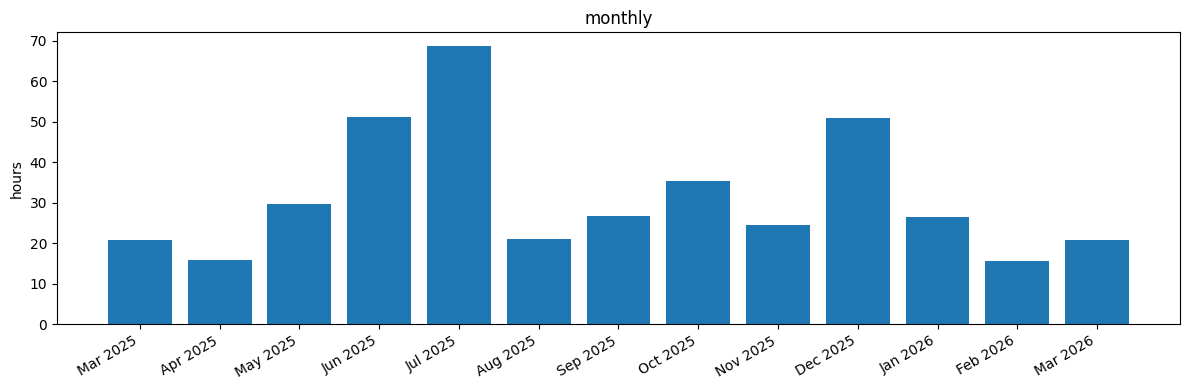

In [37]:
monthly = df.groupby('month')['hours'].sum().reset_index()
labels = [pd.Period(str(m)).strftime('%b %Y') for m in monthly['month']]

plt.figure(figsize=(12, 4))
plt.bar(labels, monthly['hours'])
plt.xticks(rotation=30, ha='right')
plt.ylabel('hours')
plt.title('monthly')
plt.tight_layout()
plt.show()

## top artist

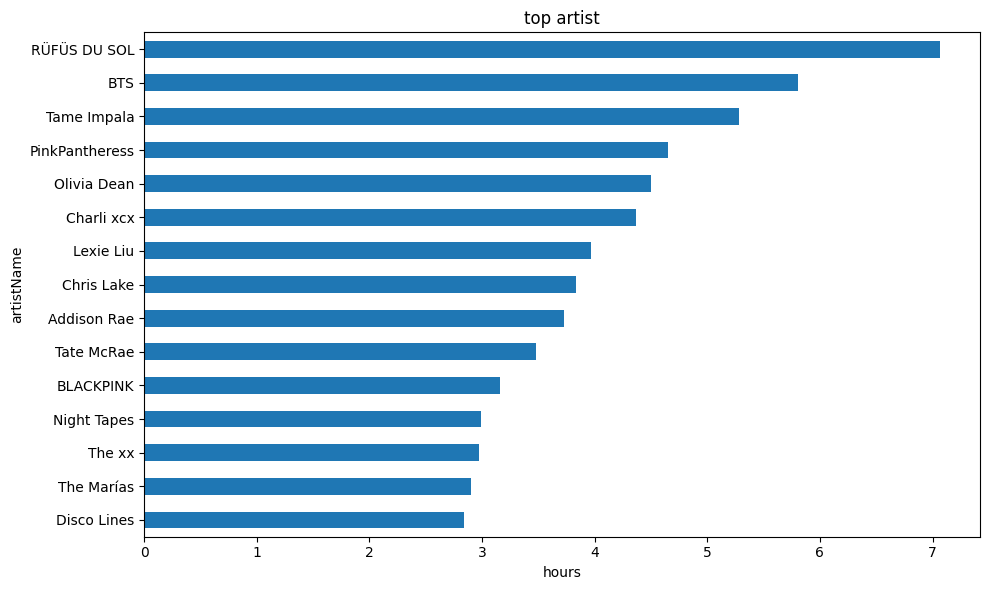

In [33]:
top_artists = df.groupby('artistName')['hours'].sum().sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
top_artists.sort_values().plot(kind='barh')
plt.xlabel('hours')
plt.title('top artist')
plt.tight_layout()
plt.show()

## top tracks

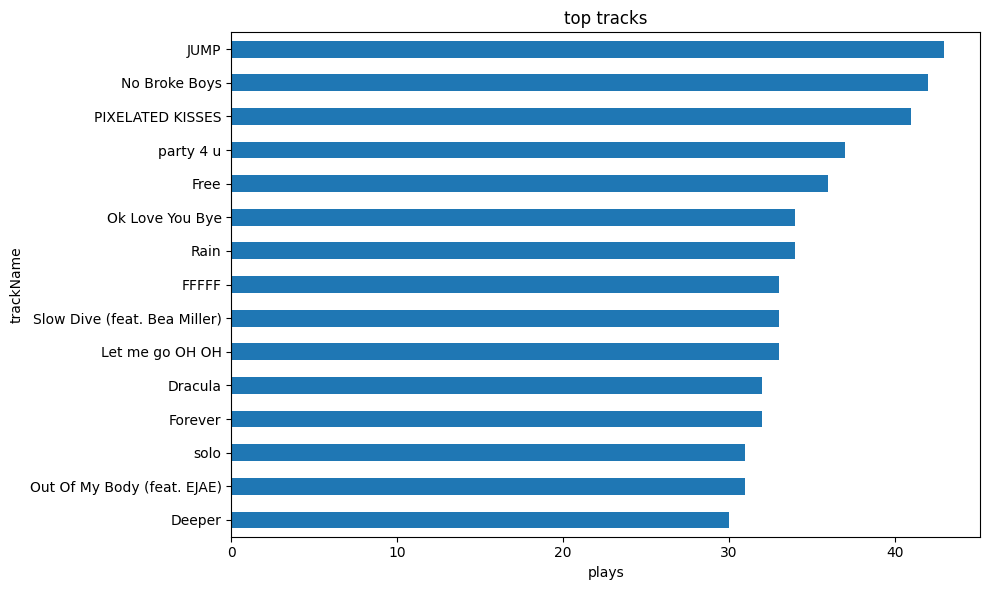

In [34]:
top_tracks = df.groupby('trackName').size().sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
top_tracks.sort_values().plot(kind='barh')
plt.xlabel('plays')
plt.title('top tracks')
plt.tight_layout()
plt.show()

## what time do i listen to my tracks and what day?

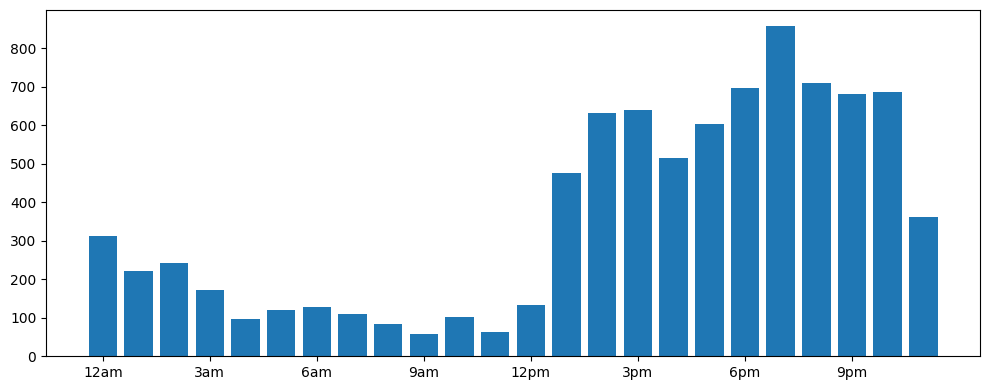

In [31]:
listened_df = df[df['msPlayed'] > 30000]
hourly = listened_df.groupby('hour').size()

plt.figure(figsize=(10, 4))
plt.bar(hourly.index, hourly.values)
plt.xticks([0,3,6,9,12,15,18,21], ['12am','3am','6am','9am','12pm','3pm','6pm','9pm'])
plt.tight_layout()
plt.show()

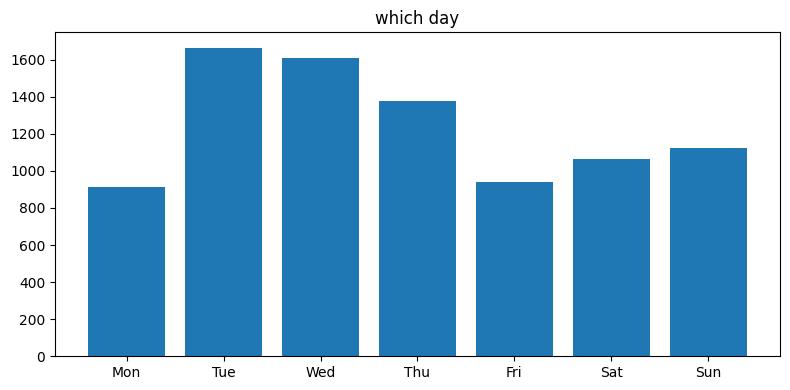

In [36]:
dow = listened_df.groupby('dow').size()

plt.figure(figsize=(8, 4))
plt.bar(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'], dow.values)
plt.title('which day')
plt.tight_layout()
plt.show()

## total listening of the year

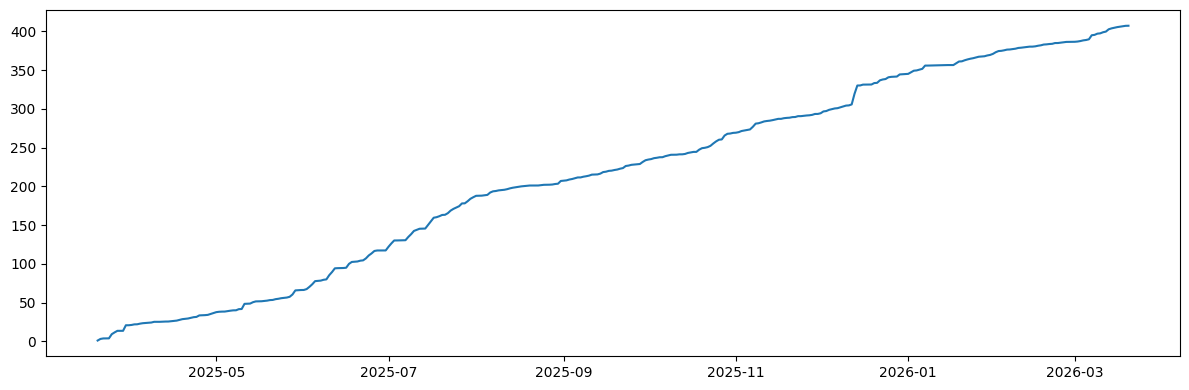

In [29]:
daily = df.groupby('date')['hours'].sum().cumsum()

plt.figure(figsize=(12, 4))
plt.plot(daily.index, daily.values)
plt.tight_layout()
plt.show()

## what songs do i listen to the most

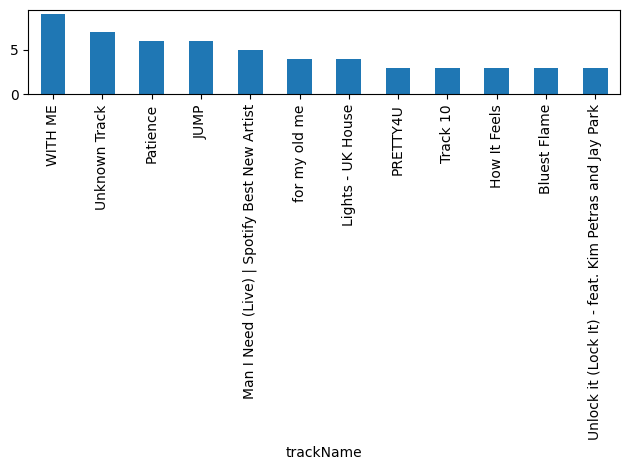

In [26]:
repeat_counts.plot(kind='bar')
plt.tight_layout()
plt.show()